# 04 - Minimum-cost ownership reconstruction for overlap-adjusted bundle attribution

The Steam dataset records which games each user owns, but not which bundles they bought. Notebook 03 worked around this by building `users_own_all`: for each bundle, the number of panel users who own every game in it.

The problem this notebook fixes: `users_own_all` is an **upper-bound compatibility count**. When two bundles share a game, a user who owns the union of both is counted toward both, even though the two bundles are competing explanations for the same library. That overlap is widespread here, and we quantify it below (278 of the 615 bundles share a game with another bundle).

This notebook resolves the ambiguity with a rational-consumer rule. For each user we ask: of all the ways they could have acquired their owned games using the available bundles and solo purchases, which is the **cheapest** under observed prices? Bundles that appear in the cheapest reconstruction get the credit.

**Important framing.** This notebook does not reconstruct historical purchases. It reconstructs the cheapest purchase path under observed snapshot prices, so the output is a cost-based attribution proxy, not a revealed purchase path. In particular, snapshot prices are not the prices each user actually faced (sales change constantly), a user could in reality have bought two overlapping bundles at different times, and ownership is not the same as purchase (gifts, giveaways, free games). The method improves *attribution*, not *identification*.

Inputs (saved by notebooks 01-03): `bundle_df` and `bundle_items_df` (bundle pricing and contents), `user_items_df` (the ownership panel), and `bundle_demand_proxy` (which carries `users_own_all` and `panel_coverage`).

What we compute per bundle:
- `candidate_ownership_count`: users who own all the bundle's games (= nb03 `users_own_all`),
- `mincost_attributed_count`: credit after resolving overlap by minimum-cost reconstruction,
- a soft-logit robustness appendix, and diagnostics of how much the raw count drops.

In [ ]:
import os
import math
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from itertools import combinations

## Load cleaned tables and build the cost model

Run notebooks 01, 02, 03 first. We use:
- `bundle_items_df` for the bundle -> items mapping and each game's standalone price,
- `bundle_df` for each bundle's `final_price` (what the bundle costs),
- `bundle_demand_proxy` for `panel_coverage` and `users_own_all` (the cross-check).

**Money is handled in integer cents** to avoid confusion. Previous outputs are turned into dictionaries simplify later algorithms.

In [4]:
bundle_items_df = pd.read_csv('../outputs/tables/bundle_items_df.csv',
                              dtype={'bundle_id': str, 'item_id': str})
bundle_df = pd.read_csv('../outputs/tables/bundle_df.csv', dtype={'bundle_id': str})
proxy_df = pd.read_csv('../outputs/tables/bundle_demand_proxy.csv', dtype={'bundle_id': str})

def to_cents(x): # convert dollars to cents
    return int(round(float(x) * 100))

# group items by bundle and convert to sets for easier comparison
bundle_item_sets = bundle_items_df.groupby('bundle_id')['item_id'].apply(frozenset).to_dict()
bundle_size = {b: len(s) for b, s in bundle_item_sets.items()} # no. of items in each bundle

# inverted index: games map to bundles containing it
item_to_bundles = defaultdict(list)
for b, s in bundle_item_sets.items():
    for it in s:
        if not pd.isna(it):
            item_to_bundles[it].append(b)

# solo price per item (min across bundles for the few inconsistent items)
solo_cents = {it: to_cents(p) for it, p in
              bundle_items_df.groupby('item_id')['item_price'].min().items()}

# bundle price in cents = final_price (after the bundle discount)
final_price = dict(zip(bundle_df['bundle_id'], bundle_df['final_price']))
bundle_price_cents = {b: to_cents(final_price[b]) for b in bundle_item_sets}

#indv sum of games in a bundle
bundle_solo_sum_cents = {b: sum(solo_cents[it] for it in s)
                         for b, s in bundle_item_sets.items()
                         if all(it in solo_cents for it in s)} # some bundles have games with no price (5)
print(f'bundles = {len(bundle_item_sets)}  items_in_bundles = {len(item_to_bundles)}  '
      f'fully-observable bundles = {len(bundle_solo_sum_cents)}')

# check for prices that cost less individually than as a bundle
solo_dominated = [b for b, ss in bundle_solo_sum_cents.items() if bundle_price_cents[b] > ss]
print(f'bundles costing more than their cheapest solo components: {len(solo_dominated)}') 
# affects only bundles with the 5 inconsistent-price items

print("615 bundles, 5 with inconsistent item prices, 2 with solo-dominated prices. 615-2-5 = 608 bundles with consistent prices.")

bundles = 615  items_in_bundles = 2797  fully-observable bundles = 608
bundles costing more than their cheapest solo components: 2
615 bundles, 5 with inconsistent item prices, 2 with solo-dominated prices. 615-2-5 = 608 bundles with consistent prices.


## How widespread is the overlap?

This section measures how often bundle item sets overlap before applying the attribution rule.
An overlap occurs when a game appears in multiple bundles, so an ownership-compatible user can be counted against more than one offer.

In [ ]:
ov_sets = (bundle_items_df.dropna(subset=['item_id']) # drop rows with missing item_id (NaN); fake overlaps
           .groupby('bundle_id')['item_id'].apply(frozenset).to_dict())

# inverted index: games map to bundles containing it
ov_inv = defaultdict(list)
for bid, items in ov_sets.items():
    for g in items: # loops pver games in that bundle ONLY
        ov_inv[g].append(bid)
games_in_multiple = {g: b for g, b in ov_inv.items() if len(b) >= 2}

overlap_pairs, overlap_bundles = [], set()
for b1, b2 in combinations(ov_sets, 2):
    if ov_sets[b1] & ov_sets[b2]:
        overlap_pairs.append((b1, b2))
        overlap_bundles.update((b1, b2))

n_total = bundle_df['bundle_id'].nunique()
print(f'bundles overlapping another bundle: {len(overlap_bundles)} / {n_total}')
print(f'overlapping bundle pairs          : {len(overlap_pairs)}')
print(f'games in 2+ bundles               : {len(games_in_multiple)}')

print("\nExamples of overlapping bundles:")
# a few examples of what an overlap looks like
for b1, b2 in overlap_pairs[:3]:
    shared = ov_sets[b1] & ov_sets[b2]
    print(f'  bundles {b1} and {b2} share {len(shared)} game(s)')

bundles overlapping another bundle: 278 / 615
overlapping bundle pairs          : 350
games in 2+ bundles               : 571

Examples of overlapping bundles:
  bundles 1007 and 1008 share 2 game(s)
  bundles 1007 and 810 share 1 game(s)
  bundles 1008 and 810 share 2 game(s)


## Per-user candidate bundles

A bundle could only have been bought by a user if all its games are in that user's library (buying the bundle gives every game, which would then be owned). So the bundles relevant to a user are exactly those whose item set is a subset of their ownership. We find them with the same single inverted-index pass used in notebook 03: count, per (user, bundle), how many of the bundle's items the user owns; the bundle is a candidate when that count equals the bundle size.

In [ ]:
user_items = pd.read_csv('../outputs/tables/user_items_df.csv',
                         usecols=['user_id', 'item_id'], dtype={'user_id': str, 'item_id': str})
print(f'ownership rows = {len(user_items):,} ') # just checking

overlap = defaultdict(int)  # number of the bundle's items the user owns (intermediate dict to avoid looping over all bundles for each user)
for uid, iid in zip(user_items['user_id'].values, user_items['item_id'].values):
    for b in item_to_bundles.get(iid, ()): # only loops over bundles containing that item
        overlap[(uid, b)] += 1

# a candidate bundle is one where the user owns all the items in it (i.e. overlap count = bundle size)
user_candidates = defaultdict(list) 
for (uid, b), k in overlap.items():
    if k == bundle_size[b]:
        user_candidates[uid].append(b)
del overlap # delete the intermediate dict to save memory
print(f'users with >=1 candidate bundle = {len(user_candidates):,})')

cand_counts = np.array([len(v) for v in user_candidates.values()])
print('candidate bundles per user: median {:.0f}, 99th pct {:.0f}, max {:.0f}'.format(
    np.median(cand_counts), np.quantile(cand_counts, 0.99), cand_counts.max()))

ownership rows = 5,094,082 
users with >=1 candidate bundle = 23,204)
candidate bundles per user: median 1, 99th pct 8, max 140


## Overlap components and the three contestation diagnostics

A user's candidate bundles are split into **overlap-connected components**: two candidate bundles are linked if they share a game. Games are partitioned across components, so each component is an independent minimum-cost subproblem over its own games. This is what keeps the computation cheap even for a user with 140 candidate bundles: the work is set by the largest component, not the total.

Three different things are easy to conflate, so we report them separately:
- **candidate_users_with_overlap**: users with two or more candidate bundles that share a game (an overlap component of size >= 2). Only here is the choice *between bundles* real.
- **users_with_multiple_feasible_decompositions**: users for whom more than one reconstruction exists at all. This is large and not a good contestation measure, because even a single candidate bundle always admits "buy the bundle" versus "buy its games solo".
- **users_with_multiple_optimal_decompositions**: users for whom the cheapest cost is tied across reconstructions. This is the only one that actually produces fractional credit, and it includes zero-discount bundles (bundle and solo cost the same), not just overlap.

In [16]:
def components_of(cands):
    '''union-find on a user's candidate bundles; link if they share an item.'''
    parent = {c: c for c in cands}
    def find(x):
        r = x
        while parent[r] != r:
            r = parent[r]
        while parent[x] != r:
            parent[x], x = r, parent[x]
        return r
    for i in range(len(cands)):
        si = bundle_item_sets[cands[i]]
        for j in range(i + 1, len(cands)):
            if si & bundle_item_sets[cands[j]]:
                ri, rj = find(cands[i]), find(cands[j])
                if ri != rj:
                    parent[ri] = rj
    groups = defaultdict(list)
    for c in cands:
        groups[find(c)].append(c)
    return [frozenset(g) for g in groups.values()]

TAUS_REPORT = [0.5, 1.0, 2.0]   # saved columns
TAU_STRESS  = 5.0               # plotted only, labelled as a stress test, not behavioural
TAU_CHECK   = 1e-4              # internal: tiny tau should reproduce the hard result
ALL_TAUS    = TAUS_REPORT + [TAU_STRESS, TAU_CHECK]

solve_cache = {}
def solve_component(comp):
    '''exact minimum-cost set cover for one component (bundles + solo fill-ins).
    returns (sorted bundles, hard inclusion fraction, soft inclusion prob per tau,
    number of optimal reconstructions).'''
    if comp in solve_cache:
        return solve_cache[comp]
    bundles = sorted(comp)
    n = len(bundles)
    bsets = [bundle_item_sets[b] for b in bundles]
    bcost = [bundle_price_cents[b] for b in bundles]
    items = sorted(set().union(*bsets))
    solo_total = sum(solo_cents[it] for it in items)
    costs = []
    best = None
    for mask in range(1 << n):
        covered = set()
        c = 0
        for i in range(n):
            if mask & (1 << i):
                covered |= bsets[i]
                c += bcost[i]
        c += solo_total - sum(solo_cents[it] for it in covered)  # uncovered bought solo
        costs.append(c)
        if best is None or c < best:
            best = c
    optimal = [m for m, c in enumerate(costs) if c == best]   # exact integer tie test
    hard = {b: sum(1 for m in optimal if m & (1 << i)) / len(optimal)
            for i, b in enumerate(bundles)}
    soft = {}
    for tau in ALL_TAUS:
        w = [math.exp(-((c - best) / 100.0) / tau) for c in costs]
        Z = sum(w)
        soft[tau] = {b: sum(w[m] for m in range(1 << n) if m & (1 << i)) / Z
                     for i, b in enumerate(bundles)}
    res = (bundles, hard, soft, len(optimal))
    solve_cache[comp] = res
    return res

# distinct components and how many user-instances each has
comp_multiplicity = Counter()
n_users_overlap = n_users_multi_feasible = n_users_multi_optimal = 0
for uid, cands in user_candidates.items():
    comps = components_of(cands)
    if any(len(c) >= 2 for c in comps):
        n_users_overlap += 1
    if len(cands) >= 1:                        # 2^(candidates) > 1 reconstructions
        n_users_multi_feasible += 1
    multi_opt = False
    for c in comps:
        comp_multiplicity[c] += 1
        if solve_component(c)[3] > 1:
            multi_opt = True
    if multi_opt:
        n_users_multi_optimal += 1

print(f'distinct components solved        : {len(solve_cache):,}')
print(f'largest component size            : {max(len(c) for c in comp_multiplicity):,}')
print(f'users with overlapping candidates : {n_users_overlap:,}')
print(f'users with >1 feasible decomp     : {n_users_multi_feasible:,}  (weak measure)')
print(f'users with >1 optimal decomp      : {n_users_multi_optimal:,}  (drives fractional credit)')

distinct components solved        : 240
largest component size            : 12
users with overlapping candidates : 173
users with >1 feasible decomp     : 23,204  (weak measure)
users with >1 optimal decomp      : 6,989  (drives fractional credit)


## Aggregate the attribution per bundle

For each distinct component we know each bundle's hard inclusion fraction and soft inclusion probability; we multiply by the number of users with that component and sum. We also build `candidate_ownership_count` (which must equal nb03 `users_own_all`) and `candidate_users_with_overlap` from the same pass.

In [6]:
mincost          = defaultdict(float)
candidate_count  = defaultdict(float)
candidate_overlap = defaultdict(float)
soft_count       = {tau: defaultdict(float) for tau in ALL_TAUS}

for comp, mult in comp_multiplicity.items():
    bundles, hard, soft, _ = solve_component(comp)
    is_overlap = len(comp) >= 2
    for b in bundles:
        candidate_count[b] += mult
        if is_overlap:
            candidate_overlap[b] += mult
        mincost[b] += hard[b] * mult
        for tau in ALL_TAUS:
            soft_count[tau][b] += soft[tau][b] * mult

# assemble one row per bundle (all 615), keeping bundles nobody fully owns
out = bundle_df[['bundle_id', 'bundle_name', 'n_items', 'final_price',
                 'component_price_sum', 'implied_discount_rate']].copy()
out = out.merge(proxy_df[['bundle_id', 'panel_coverage', 'users_own_all']],
                on='bundle_id', how='left')

out['candidate_ownership_count'] = out['bundle_id'].map(candidate_count).fillna(0.0)
out['mincost_attributed_count']  = out['bundle_id'].map(mincost).fillna(0.0)
out['candidate_users_with_overlap'] = out['bundle_id'].map(candidate_overlap).fillna(0.0)
out['attribution_rate_given_candidate'] = np.where(
    out['candidate_ownership_count'] > 0,
    out['mincost_attributed_count'] / out['candidate_ownership_count'], np.nan)
out['contested_candidate_share'] = np.where(
    out['candidate_ownership_count'] > 0,
    out['candidate_users_with_overlap'] / out['candidate_ownership_count'], np.nan)
out['attributed_revenue_proxy'] = out['final_price'] * out['mincost_attributed_count']
for tau, name in [(0.5, 'tau_0_5'), (1.0, 'tau_1'), (2.0, 'tau_2')]:
    out['soft_mincost_attributed_' + name] = out['bundle_id'].map(soft_count[tau]).fillna(0.0)

print(out[['bundle_name', 'candidate_ownership_count', 'mincost_attributed_count',
           'attribution_rate_given_candidate', 'contested_candidate_share']]
      .sort_values('candidate_ownership_count', ascending=False).head(10).to_string(index=False))

                                                     bundle_name  candidate_ownership_count  mincost_attributed_count  attribution_rate_given_candidate  contested_candidate_share
                                                   Portal Bundle                    13837.0                   13837.0                          1.000000                   0.000000
                                            BioShock Triple Pack                     6951.0                    3475.5                          0.500000                   0.000000
                                              Left 4 Dead Bundle                     5890.0                    5890.0                          1.000000                   0.000000
                                           Half-Life 1 Anthology                     5832.0                    5832.0                          1.000000                   0.000000
                                         Source Multiplayer Pack                     4028.0              

## Sanity checks

These assert the method behaves as designed, using exact integer-cent comparisons.

In [7]:
eps = 1e-6
# 1. resolving overlap can only remove credit, never add it.
assert (out['mincost_attributed_count'] <= out['candidate_ownership_count'] + eps).all()

# 2. candidate_ownership_count must reproduce nb03 users_own_all exactly.
chk = out.dropna(subset=['users_own_all'])
assert np.allclose(chk['candidate_ownership_count'], chk['users_own_all'])

# 3. a full-coverage, non-overlapping bundle that is STRICTLY cheaper than buying its games
#    at the solver's own solo prices keeps all its credit (unique optimum).
strict = out[(out['panel_coverage'] == 1.0)
             & (out['candidate_users_with_overlap'] == 0)
             & (out['candidate_ownership_count'] > 0)
             & out['bundle_id'].map(lambda b: bundle_price_cents[b] < bundle_solo_sum_cents.get(b, -1))]
assert np.allclose(strict['mincost_attributed_count'], strict['candidate_ownership_count'])
print(f'check 3 held on {len(strict)} strictly-discounted full-coverage non-overlapping bundles')

# 4. a tiny temperature reproduces the hard fractional-tie result.
soft_check = out['bundle_id'].map(soft_count[TAU_CHECK]).fillna(0.0)
assert np.allclose(soft_check, out['mincost_attributed_count'], atol=1e-4)
print('all sanity checks passed')

out.to_csv('../outputs/tables/bundle_mincost_attribution.csv', index=False)
print('saved bundle_mincost_attribution.csv')

check 3 held on 133 strictly-discounted full-coverage non-overlapping bundles
all sanity checks passed
saved bundle_mincost_attribution.csv


## Diagnostics: how much does resolving overlap change the picture?

`lost_share` is the fraction of a bundle's raw ownership-completion count that is reassigned once overlap is resolved. The bundles with the biggest drops are the ones whose apparent demand in notebook 03 was most inflated by shared games.

In [8]:
out['lost_count'] = out['candidate_ownership_count'] - out['mincost_attributed_count']
out['lost_share'] = np.where(out['candidate_ownership_count'] > 0,
                             out['lost_count'] / out['candidate_ownership_count'], np.nan)

total_cand = out['candidate_ownership_count'].sum()
total_attr = out['mincost_attributed_count'].sum()
print(f'total candidate-ownership count : {total_cand:,.0f}')
print(f'total min-cost attributed count : {total_attr:,.1f}')
print(f'overall share reassigned        : {1 - total_attr/total_cand:.1%}\n')

full = out[out['panel_coverage'] == 1.0]
cols = ['bundle_name', 'n_items', 'candidate_ownership_count', 'mincost_attributed_count',
        'lost_share', 'contested_candidate_share']
print('full-coverage bundles with the largest drop (min 50 candidate owners):')
print(full[full['candidate_ownership_count'] >= 50]
      .sort_values('lost_share', ascending=False)[cols].head(12).round(3).to_string(index=False))

total candidate-ownership count : 46,122
total min-cost attributed count : 42,237.0
overall share reassigned        : 8.4%

full-coverage bundles with the largest drop (min 50 candidate owners):
                                 bundle_name  n_items  candidate_ownership_count  mincost_attributed_count  lost_share  contested_candidate_share
                         Interstellar Bundle        4                       79.0                       5.0       0.937                      1.000
                        BioShock Triple Pack        3                     6951.0                    3475.5       0.500                      0.000
                    Stronghold Complete Pack        2                       65.0                      32.5       0.500                      0.000
              Hero of the Kingdom Collection        2                       59.0                      46.0       0.220                      0.220
                                Space Bundle        3                      

## What is actually being reassigned: overlap versus zero-discount ties

The total reassignment splits into two very different mechanisms, and conflating them would overstate the overlap problem:
- **Overlap resolution** (the method's purpose): users who owned the union of competing bundles, where the cheapest reconstruction picks some bundles over others.
- **Zero-discount / solo-dominated ties**: a bundle with no discount costs exactly the same as buying its games solo, so the cost rule is genuinely indifferent and splits the credit. This has nothing to do with overlap.

A bundle with `candidate_users_with_overlap == 0` never competes with another bundle for any user, so all of its reassignment is the second kind.

In [9]:
overlap_bundle = out['candidate_users_with_overlap'] > 0
lost_overlap = out.loc[overlap_bundle, 'lost_count'].sum()
lost_tie = out.loc[~overlap_bundle, 'lost_count'].sum()
print(f'total reassigned mass            : {out["lost_count"].sum():,.1f}')
print(f'  from overlap-affected bundles  : {lost_overlap:,.1f}   <- the overlap correction')
print(f'  from non-overlap bundles       : {lost_tie:,.1f}   <- pure zero-discount ties\n')

print('largest single contributors to reassignment:')
print(out.sort_values('lost_count', ascending=False)
      [['bundle_name', 'implied_discount_rate', 'candidate_users_with_overlap',
        'candidate_ownership_count', 'mincost_attributed_count', 'lost_count']]
      .head(6).round(3).to_string(index=False))

print('\ntakeaway: the overlap adjustment the method was built for is small in this catalogue;'
      '\nmost of the headline reassignment is one zero-discount bundle where the cost rule'
      '\ncannot distinguish buying the bundle from buying its games separately.')

total reassigned mass            : 3,885.0
  from overlap-affected bundles  : 367.0   <- the overlap correction
  from non-overlap bundles       : 3,518.0   <- pure zero-discount ties

largest single contributors to reassignment:
                           bundle_name  implied_discount_rate  candidate_users_with_overlap  candidate_ownership_count  mincost_attributed_count  lost_count
                  BioShock Triple Pack                  0.000                           0.0                     6951.0                    3475.5      3475.5
                   Interstellar Bundle                  0.568                          79.0                       79.0                       5.0        74.0
              Stronghold Complete Pack                  0.000                           0.0                       65.0                      32.5        32.5
Platformer Bundle by New Reality Games                  0.504                          27.0                       27.0                       0

## Plots

Left: the raw count versus the attributed count for full-coverage bundles, on log axes, with the y = x line. Points below the line lost credit, whether from overlap or a zero-discount tie. Right: the full-coverage bundles with the largest drop (a mix of both mechanisms), raw versus attributed, with the soft-logit stress test (tau = 5, not a behavioural estimate) shown as a marker to bound the sensitivity.

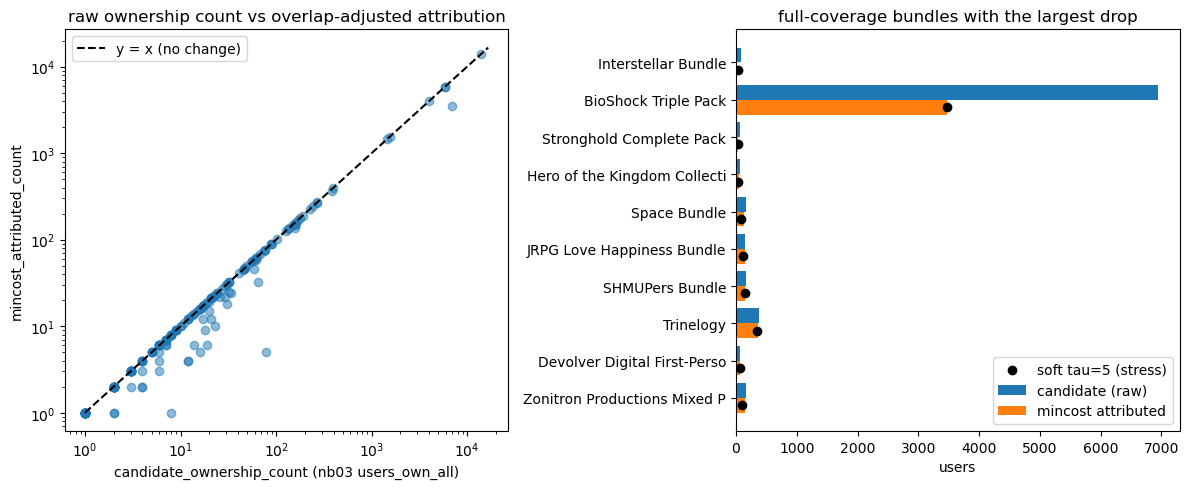

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
f = full[full['candidate_ownership_count'] > 0]
ax.scatter(f['candidate_ownership_count'], f['mincost_attributed_count'], alpha=0.5)
lim = [1, f['candidate_ownership_count'].max() * 1.2]
ax.plot(lim, lim, 'k--', label='y = x (no change)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('candidate_ownership_count (nb03 users_own_all)')
ax.set_ylabel('mincost_attributed_count')
ax.set_title('raw ownership count vs overlap-adjusted attribution')
ax.legend()

ax = axes[1]
top = (full[full['candidate_ownership_count'] >= 50]
       .sort_values('lost_share', ascending=False).head(10).iloc[::-1])
y = np.arange(len(top))
soft5 = top['bundle_id'].map(soft_count[TAU_STRESS])
ax.barh(y + 0.2, top['candidate_ownership_count'], height=0.4, label='candidate (raw)')
ax.barh(y - 0.2, top['mincost_attributed_count'], height=0.4, label='mincost attributed')
ax.scatter(soft5, y - 0.2, color='black', label='soft tau=5 (stress)')
ax.set_yticks(y)
ax.set_yticklabels([n[:28] for n in top['bundle_name']])
ax.set_xlabel('users')
ax.set_title('full-coverage bundles with the largest drop')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/04_mincost_attribution.png')
plt.show()

## What this shows

`mincost_attributed_count` is the overlap-adjusted demand proxy. It equals `users_own_all` for bundles whose games are not shared and that are genuinely discounted, and it falls below it in two cases that the diagnostics keep separate: where overlapping bundles compete for the same owners (the intended correction), and where a zero-discount bundle ties with buying its games solo (a consequence of the cost rule, not of overlap).

The headline finding for this catalogue is that the overlap correction is small: of the ~3,900 reassigned units, only ~370 come from overlap, while the rest is dominated by a single zero-discount bundle (BioShock Triple Pack) that the cost rule cannot attribute. So for most bundles the simple `users_own_all` count was not badly inflated by overlap, which is itself a useful, honest result. The overlap adjustment matters mainly for a handful of small bundles (Interstellar, Space, JRPG, Platformer) with high `contested_candidate_share`.

This is a cost-based attribution under snapshot prices, not a record of purchases, and it is trusted on full-coverage bundles only (panel_coverage == 1.0), for the reasons in the introduction and in notes/assumptions_and_limitations.md. For notebook 05, the choice between `users_own_all` and `mincost_attributed_count` matters little except for the zero-discount bundles, where neither is clearly right and the bundle should probably be flagged separately. Later this attribution can serve as a consistency check for the valuation model.